# Proyecto: Predicción de Churn en Distribución de Streaming

## Contexto del Negocio
Este proyecto se desarrolla dentro de un modelo de emprendimiento enfocado en la **distribución y reventa de perfiles de plataformas de streaming** (MAX, Netflix, Crunchyroll, etc.).

### Objetivos
- **Variable Target (objetivo):** `churn` (0 = cliente activo, 1 = cliente que abandonó)
- **Técnica básica:** Regresión Logística
- **Técnica avanzada:** Random Forest (comparación de al menos 2 técnicas)

### Cronograma
| Semana | Actividad |
|--------|----------|
| 1 | Dataset, objetivos y cronograma |
| 2 | Preprocesamiento y análisis estadístico |
| 3 | Selección de variables y Regresión Logística |
| 4 | Random Forest y comparación de técnicas |
| 5 | Entrega final y documentación |

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')
print('Librerías importadas correctamente')

/home/bryan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Librerías importadas correctamente


## 2. Carga del Dataset

In [2]:
df = pd.read_csv('dataset_streaming_limpio.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
df.head(10)

Dimensiones del dataset: (245, 8)

Columnas: ['id_cliente', 'plataforma', 'duracion_plan', 'duracion_meses', 'tipo_plan', 'mes_inicio', 'tiene_fecha_inicio', 'churn']


,id_cliente,plataforma,duracion_plan,duracion_meses,tipo_plan,mes_inicio,tiene_fecha_inicio,churn
0,CLIENTE_0001,MAX,1 año,12,largo,11,0,0
1,CLIENTE_0002,MAX,1 año,12,largo,5,1,1
2,CLIENTE_0003,MAX,6 meses,6,largo,9,1,1
3,CLIENTE_0004,MAX,1 mes,1,corto,2,1,1
4,CLIENTE_0005,MAX,1 año,12,largo,8,1,0
5,CLIENTE_0006,MAX,3 meses,3,medio,4,1,0
6,CLIENTE_0007,Crunchyroll,1 año,12,largo,5,1,1
7,CLIENTE_0008,Crunchyroll,1 año,12,largo,5,1,1
8,CLIENTE_0009,Crunchyroll,1 año,12,largo,5,1,1
9,CLIENTE_0010,Crunchyroll,1 año,12,largo,11,1,0


## 3. Inspección Inicial del Dataset

In [3]:
print('=== INFORMACIÓN DEL DATASET ===')
print(df.info())
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe()

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_cliente          245 non-null    object
 1   plataforma          245 non-null    object
 2   duracion_plan       245 non-null    object
 3   duracion_meses      245 non-null    int64 
 4   tipo_plan           245 non-null    object
 5   mes_inicio          245 non-null    int64 
 6   tiene_fecha_inicio  245 non-null    int64 
 7   churn               245 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 15.4+ KB
None

=== ESTADÍSTICAS DESCRIPTIVAS ===


,duracion_meses,mes_inicio,tiene_fecha_inicio,churn
count,245.000000,245.000000,245.000000,245.000000
mean,8.640816,6.697959,0.959184,0.265306
std,4.747904,3.487477,0.198270,0.442400
min,1.000000,1.000000,0.000000,0.000000
25%,3.000000,3.000000,1.000000,0.000000
50%,12.000000,7.000000,1.000000,0.000000
75%,12.000000,10.000000,1.000000,1.000000
max,12.000000,12.000000,1.000000,1.000000


In [4]:
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print(f'\n=== DISTRIBUCIÓN DEL TARGET (churn) ===')
print(df['churn'].value_counts())
print(f'\nTasa de Churn: {df["churn"].mean():.2%}')

=== VALORES NULOS ===
id_cliente            0
plataforma            0
duracion_plan         0
duracion_meses        0
tipo_plan             0
mes_inicio            0
tiene_fecha_inicio    0
churn                 0
dtype: int64

=== DISTRIBUCIÓN DEL TARGET (churn) ===
churn
0    180
1     65
Name: count, dtype: int64

Tasa de Churn: 26.53%


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución de la Variable Target

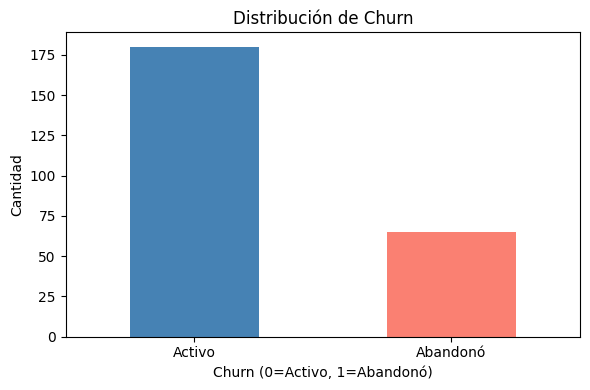

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Distribución de Churn')
ax.set_xlabel('Churn (0=Activo, 1=Abandonó)')
ax.set_ylabel('Cantidad')
ax.set_xticklabels(['Activo', 'Abandonó'], rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Distribución por Plataforma

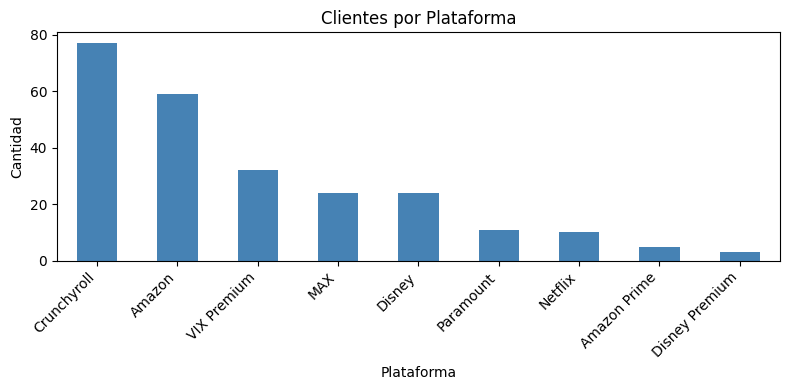

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
df['plataforma'].value_counts().plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Clientes por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Churn por Duración del Plan

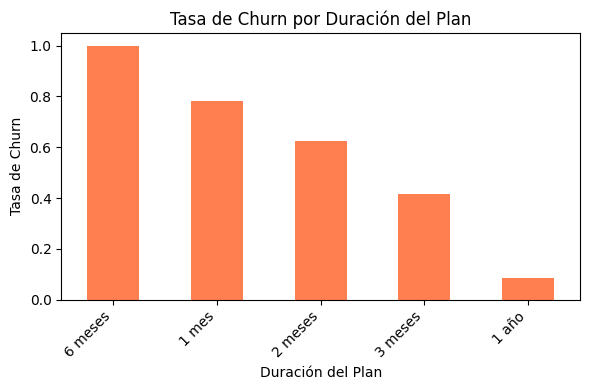

In [7]:
churn_por_duracion = df.groupby('duracion_plan')['churn'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
churn_por_duracion.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Tasa de Churn por Duración del Plan')
ax.set_xlabel('Duración del Plan')
ax.set_ylabel('Tasa de Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.4 Churn por Plataforma

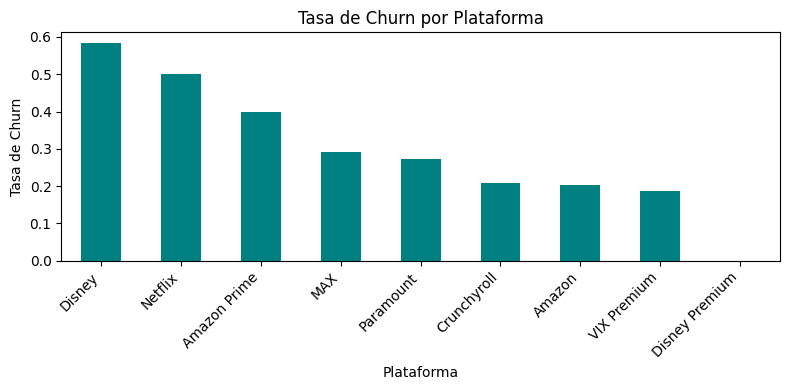

In [8]:
churn_por_plat = df.groupby('plataforma')['churn'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
churn_por_plat.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Tasa de Churn por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Tasa de Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Preprocesamiento de Datos

### 5.1 Codificación de Variables Categóricas

In [9]:
# Codificar variables categóricas
le_plataforma = LabelEncoder()
le_tipo_plan = LabelEncoder()

df['plataforma_encoded'] = le_plataforma.fit_transform(df['plataforma'])
df['tipo_plan_encoded'] = le_tipo_plan.fit_transform(df['tipo_plan'])

print('Mapeo de Plataforma:')
for i, clase in enumerate(le_plataforma.classes_):
    print(f'  {clase} -> {i}')

print('\nMapeo de Tipo de Plan:')
for i, clase in enumerate(le_tipo_plan.classes_):
    print(f'  {clase} -> {i}')

Mapeo de Plataforma:
  Amazon -> 0
  Amazon Prime -> 1
  Crunchyroll -> 2
  Disney -> 3
  Disney Premium -> 4
  MAX -> 5
  Netflix -> 6
  Paramount -> 7
  VIX Premium -> 8

Mapeo de Tipo de Plan:
  corto -> 0
  largo -> 1
  medio -> 2


### 5.2 Selección de Variables Predictoras

In [10]:
# Variables predictoras (features)
features = ['duracion_meses', 'plataforma_encoded', 'tipo_plan_encoded',
             'mes_inicio', 'tiene_fecha_inicio']

X = df[features].copy()
y = df['churn'].copy()

print(f'Features seleccionadas: {features}')
print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print(f'\nPrimeras filas de X:')
X.head()

Features seleccionadas: ['duracion_meses', 'plataforma_encoded', 'tipo_plan_encoded', 'mes_inicio', 'tiene_fecha_inicio']
Shape de X: (245, 5)
Shape de y: (245,)

Primeras filas de X:


,duracion_meses,plataforma_encoded,tipo_plan_encoded,mes_inicio,tiene_fecha_inicio
0,12,5,1,11,0
1,12,5,1,5,1
2,6,5,1,9,1
3,1,5,0,2,1
4,12,5,1,8,1


### 5.3 Matriz de Correlación

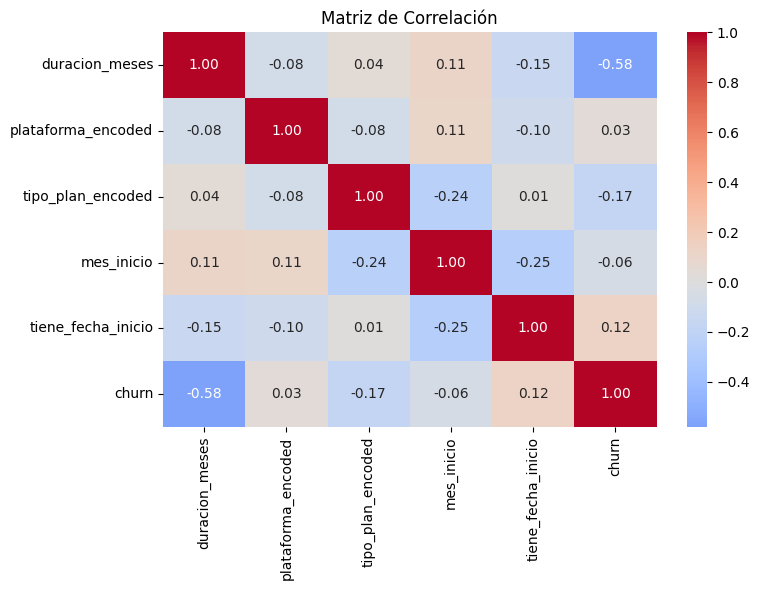

In [11]:
# Agregar target para la correlación
df_corr = X.copy()
df_corr['churn'] = y

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Matriz de Correlación')
plt.tight_layout()
plt.show()

### 5.4 División Train/Test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')
print(f'\nDistribución de churn en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución de churn en prueba:')
print(y_test.value_counts())

Conjunto de entrenamiento: 183 muestras
Conjunto de prueba: 62 muestras

Distribución de churn en entrenamiento:
churn
0    134
1     49
Name: count, dtype: int64

Distribución de churn en prueba:
churn
0    46
1    16
Name: count, dtype: int64


### 5.5 Escalamiento de Features

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente')
print(f'Media de X_train_scaled: {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std de X_train_scaled: {X_train_scaled.std(axis=0).round(4)}')

Datos escalados correctamente
Media de X_train_scaled: [ 0. -0. -0.  0.  0.]
Std de X_train_scaled: [1. 1. 1. 1. 1.]


## 6. Técnica 1: Regresión Logística

### 6.1 Entrenamiento del Modelo

In [14]:
# Crear y entrenar el modelo de Regresión Logística
lr = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

print('Modelo de Regresión Logística entrenado')
print(f'\nIntercepto (w0): {lr.intercept_[0]:.4f}')
print(f'\nCoeficientes:')
for feat, coef in zip(features, lr.coef_[0]):
    print(f'  {feat}: {coef:.4f}')

Modelo de Regresión Logística entrenado

Intercepto (w0): -1.3272

Coeficientes:
  duracion_meses: -1.2405
  plataforma_encoded: 0.0045
  tipo_plan_encoded: -0.3707
  mes_inicio: -0.0630
  tiene_fecha_inicio: 0.4322


### 6.2 Predicciones

In [15]:
# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_probs_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Primeras 10 predicciones vs valores reales:')
for i in range(min(10, len(y_test))):
    real = y_test.iloc[i]
    pred = y_pred_lr[i]
    prob = y_probs_lr[i]
    print(f'  Real: {real} | Predicción: {pred} | P(churn): {prob:.4f}')

Primeras 10 predicciones vs valores reales:
  Real: 0 | Predicción: 0 | P(churn): 0.1073
  Real: 0 | Predicción: 0 | P(churn): 0.1055
  Real: 0 | Predicción: 0 | P(churn): 0.1021
  Real: 0 | Predicción: 0 | P(churn): 0.1172
  Real: 0 | Predicción: 0 | P(churn): 0.1021
  Real: 0 | Predicción: 0 | P(churn): 0.1007
  Real: 1 | Predicción: 1 | P(churn): 0.7978
  Real: 0 | Predicción: 0 | P(churn): 0.1160
  Real: 0 | Predicción: 0 | P(churn): 0.0119
  Real: 0 | Predicción: 0 | P(churn): 0.4811


### 6.3 Evaluación - Regresión Logística

In [16]:
# Métricas
print('=== REPORTE DE CLASIFICACIÓN - Regresión Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Activo', 'Churn']))

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')

=== REPORTE DE CLASIFICACIÓN - Regresión Logística ===
              precision    recall  f1-score   support

      Activo       0.83      0.93      0.88        46
       Churn       0.70      0.44      0.54        16

    accuracy                           0.81        62
   macro avg       0.76      0.69      0.71        62
weighted avg       0.79      0.81      0.79        62

Accuracy: 0.8065


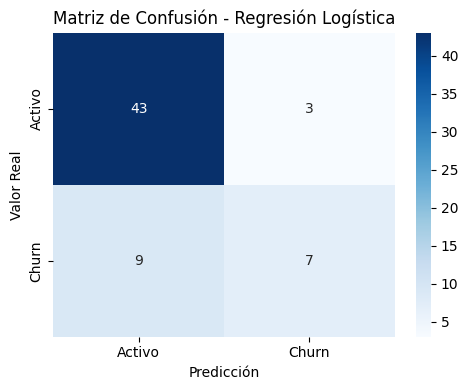

In [17]:
# Matriz de Confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Activo', 'Churn'], yticklabels=['Activo', 'Churn'])
ax.set_title('Matriz de Confusión - Regresión Logística')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()

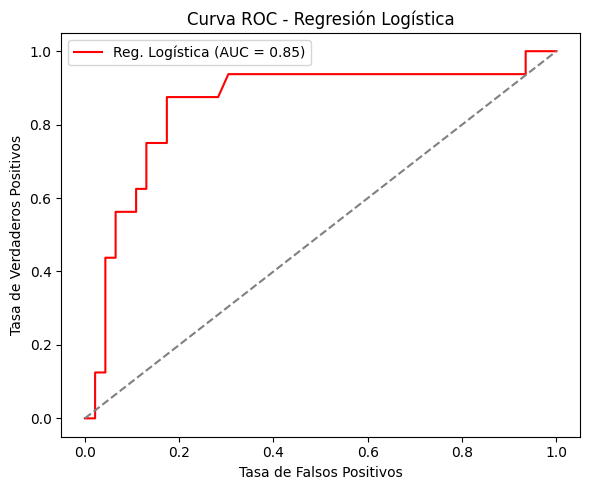

ROC-AUC Score: 0.8539


In [18]:
# Curva ROC
auc_lr = roc_auc_score(y_test, y_probs_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='red', label=f'Reg. Logística (AUC = {auc_lr:.2f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC - Regresión Logística')
ax.legend()
plt.tight_layout()
plt.show()
print(f'ROC-AUC Score: {auc_lr:.4f}')

## 7. Técnica 2: Random Forest

### 7.1 Entrenamiento del Modelo

In [19]:
# Crear y entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_train_scaled, y_train)

print('Modelo Random Forest entrenado')
print(f'\nImportancia de las features:')
for feat, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f'  {feat}: {imp:.4f}')

Modelo Random Forest entrenado

Importancia de las features:


  duracion_meses: 0.3425
  mes_inicio: 0.2575
  tipo_plan_encoded: 0.2403
  plataforma_encoded: 0.1556
  tiene_fecha_inicio: 0.0040


### 7.2 Predicciones

In [20]:
y_pred_rf = rf.predict(X_test_scaled)
y_probs_rf = rf.predict_proba(X_test_scaled)[:, 1]

print('Primeras 10 predicciones vs valores reales:')
for i in range(min(10, len(y_test))):
    real = y_test.iloc[i]
    pred = y_pred_rf[i]
    prob = y_probs_rf[i]
    print(f'  Real: {real} | Predicción: {pred} | P(churn): {prob:.4f}')

Primeras 10 predicciones vs valores reales:
  Real: 0 | Predicción: 0 | P(churn): 0.0371
  Real: 0 | Predicción: 0 | P(churn): 0.0344
  Real: 0 | Predicción: 0 | P(churn): 0.0242
  Real: 0 | Predicción: 0 | P(churn): 0.4473
  Real: 0 | Predicción: 0 | P(churn): 0.0242
  Real: 0 | Predicción: 0 | P(churn): 0.1580
  Real: 1 | Predicción: 1 | P(churn): 0.9929
  Real: 0 | Predicción: 0 | P(churn): 0.2253
  Real: 0 | Predicción: 0 | P(churn): 0.0223
  Real: 0 | Predicción: 0 | P(churn): 0.4467


### 7.3 Evaluación - Random Forest

In [21]:
print('=== REPORTE DE CLASIFICACIÓN - Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Activo', 'Churn']))

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {acc_rf:.4f}')

=== REPORTE DE CLASIFICACIÓN - Random Forest ===
              precision    recall  f1-score   support

      Activo       0.88      0.93      0.91        46
       Churn       0.77      0.62      0.69        16

    accuracy                           0.85        62
   macro avg       0.82      0.78      0.80        62
weighted avg       0.85      0.85      0.85        62

Accuracy: 0.8548


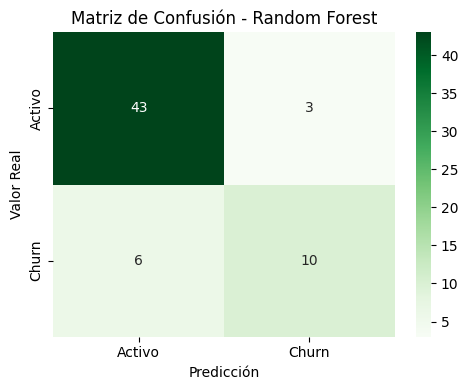

In [22]:
# Matriz de Confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Activo', 'Churn'], yticklabels=['Activo', 'Churn'])
ax.set_title('Matriz de Confusión - Random Forest')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()

### 7.4 Importancia de Features

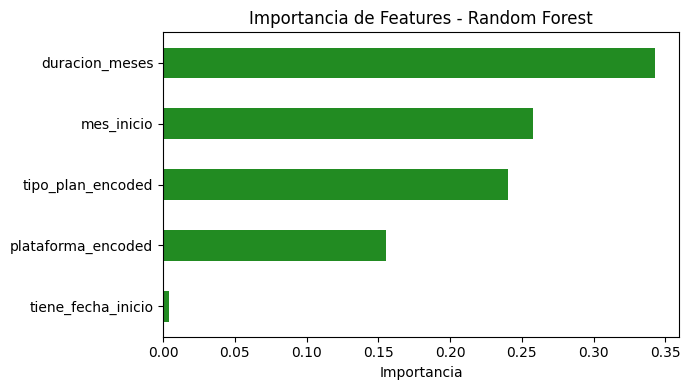

In [23]:
importancias = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot(kind='barh', color='forestgreen', ax=ax)
ax.set_title('Importancia de Features - Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## 8. Comparación de Modelos

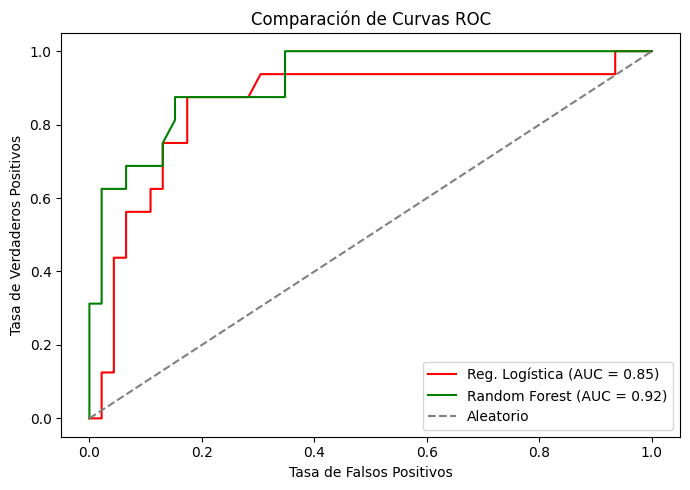

In [24]:
# Curvas ROC comparativas
auc_rf = roc_auc_score(y_test, y_probs_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='red', label=f'Reg. Logística (AUC = {auc_lr:.2f})')
ax.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest (AUC = {auc_rf:.2f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Comparación de Curvas ROC')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf],
    'ROC-AUC': [auc_lr, auc_rf]
})
print('=== COMPARACIÓN FINAL DE MODELOS ===')
print(comparacion.to_string(index=False))

mejor = 'Regresión Logística' if auc_lr > auc_rf else 'Random Forest'
print(f'\nMejor modelo según ROC-AUC: {mejor}')

=== COMPARACIÓN FINAL DE MODELOS ===
             Modelo  Accuracy  ROC-AUC
Regresión Logística  0.806452 0.853940
      Random Forest  0.854839 0.919158

Mejor modelo según ROC-AUC: Random Forest


## 9. Conclusiones

### Hallazgos Principales
1. Se procesaron datos reales del negocio de distribución de streaming (~245 registros)
2. La tasa de churn observada es de aproximadamente 26%, indicando que 1 de cada 4 clientes abandona
3. Los planes de corta duración (1 mes) presentan tasas de churn más altas
4. Se implementaron y compararon 2 técnicas de clasificación: Regresión Logística y Random Forest

### Aplicación al Negocio
- El modelo permite **anticipar bajas** antes de que venzan las suscripciones
- Permite diseñar **campañas de retención** dirigidas a clientes con alta probabilidad de churn
- La variable `duracion_meses` es un predictor importante del churn